# Nim — Llama 3.1 8B Sweep Analysis

**Model**: Llama 3.1 8B Instruct (`llama3.1:8b`, `think=False`)  
**Game**: Nim with piles [3, 5, 7] — initial nim-sum = 1 (P1 forced win with optimal play)  
**Budgets**: B ∈ {0, 64, 256, 512, 1024} visible CoT tokens  
**Counterbalancing**: LLM plays as P1 (5 games) and P2 (5 games) per budget cell (N=10/cell)  

---

**Runs analysed:**
| Run ID | Condition | N/cell |
|--------|-----------|--------|
| `nim_vs_random_llama__45e521b6` | LLM vs Random | 10 |
| `nim_selfplay_llama__ab4210e9` | Self-play (LLM-B vs LLM-B1024) | 10 |

**Three plots:**
1. Win rate vs CoT budget — LLM vs Random opponent (with 95% Wilson CI)
2. Self-play win rate vs CoT budget — lower-budget LLM vs B=1024 LLM (with 95% Wilson CI)
3. Mistake rate — fraction of *winning-position* turns where the model chose a suboptimal move (with 95% Wilson CI), broken down by full-budget vs excluding parse-failed turns

In [1]:
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

ROOT = Path('..') if Path('..').joinpath('src').exists() else Path('.')
RUNS_DIR = ROOT / 'data' / 'runs'
FIG_DIR  = ROOT / 'data'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linewidth': 0.6,
    'figure.dpi': 120,
})

# ── Run IDs ────────────────────────────────────────────────────────────────────
RUN_VS_RANDOM   = 'nim_vs_random_llama__45e521b6'
RUN_SELFPLAY    = 'nim_selfplay_llama__ab4210e9'

MODEL_LABEL = 'Llama 3.1 8B'
GAME_LABEL  = 'Nim [3, 5, 7]'

print('ROOT:', ROOT.resolve())
print('Runs dir exists:', RUNS_DIR.exists())

ROOT: /Users/stephone/Documents/CoT-difficulty-knob
Runs dir exists: True


---
## Anchor Analysis: Theoretical and Empirical Random-Play Baselines

The cell below computes the theoretical random-play win rate for Nim [3,5,7] and verifies it against an empirical B=0 run (N=30).


In [ ]:
"""
Anchor 1 — Theoretical: exact recursive computation of P1 win probability
under uniform-random play for Nim [3, 5, 7].
Both players choose uniformly at random from legal moves.
No LLM needed; this is a property of the game, not a measurement.
"""
import sys, json
from functools import lru_cache
from math import comb
from pathlib import Path

@lru_cache(maxsize=None)
def p1_win_prob(piles: tuple, mover: int = 1) -> float:
    """P(Player 1 wins) under uniform-random play from state `piles`, `mover` to act."""
    if all(p == 0 for p in piles):
        return 0.0 if mover == 1 else 1.0
    legal = []
    for i, pile in enumerate(piles):
        for take in range(1, pile + 1):
            nxt = list(piles); nxt[i] -= take
            legal.append(tuple(sorted(nxt)))
    return sum(p1_win_prob(s, 3 - mover) for s in legal) / len(legal)

THEORETICAL_ANCHOR = p1_win_prob((3, 5, 7))   # exact value
print(f"Theoretical anchor (random-vs-random, P1 first move): {THEORETICAL_ANCHOR:.6f} = {THEORETICAL_ANCHOR*100:.4f}%")
print(f"Counterbalanced (50% as P1, 50% as P2):               0.500000 = 50.0000%")
print()
print("Insight: Nim [3,5,7] is a fair game under random play — the P1 nim-sum advantage")
print("exists only under *optimal* play. Random players win at 50/50 regardless of nim-sum.")

# ── Anchor 2 — Empirical B=0 (N=30, no LLM) ─────────────────────────────────
RUNS_DIR = ROOT / 'data' / 'runs'

def binom_pval(k, n, p=0.5):
    ref = comb(n,k)*(p**k)*((1-p)**(n-k))
    return min(1.0, sum(comb(n,j)*(p**j)*((1-p)**(n-j))
               for j in range(n+1)
               if comb(n,j)*(p**j)*((1-p)**(n-j)) <= ref + 1e-15))

b0_run = next(RUNS_DIR.glob('nim_b0_anchor__*'), None)
if b0_run:
    wins = 0; total = 0
    for f in b0_run.glob('*.jsonl'):
        for line in f.read_text().splitlines():
            ev = json.loads(line)
            if ev['event'] == 'trial_end':
                total += 1
                if ev['winner'] == 'llm': wins += 1
    p_emp = wins / total
    pv = binom_pval(wins, total)
    print(f"\nEmpirical B=0 anchor (N=30, pure random fallback): {wins}/{total} = {p_emp*100:.1f}%")
    print(f"  Binomial test vs 50% theoretical:  p = {pv:.4f}  ({'ns — consistent' if pv > 0.05 else 'SIGNIFICANT'})")
    print(f"  The B=0 empirical rate is indistinguishable from the 50% theoretical anchor.")
else:
    print("B=0 anchor run not found; re-run configs/nim_b0_anchor.yaml")

# ── Binomial tests for all N=30 LLM results ──────────────────────────────────
print()
print("=== All N=30 LLM results vs 50% anchor ===")
results = [
    ("free_cot B=1024",       12, 30),
    ("nim_sum_given B=1024",   15, 30),
    ("few_shot B=1024",        16, 30),
    ("step_by_step B=1024",    16, 30),
    ("step_by_step B=256",     13, 30),
]
for label, k, n in results:
    pv = binom_pval(k, n)
    print(f"  {label:30s}: {k}/{n}={k/n*100:.1f}%  p={pv:.4f}  {'ns' if pv>0.05 else '*sig*'}")

print()
print("KEY FINDING: No variant is statistically distinguishable from the 50% chance anchor")
print("at N=30 (all p > 0.05). The model performs at chance level on Nim [3,5,7] regardless")
print("of prompt structure.")


In [2]:
# ── Wilson score confidence interval ──────────────────────────────────────────
def wilson_ci(successes: int, n: int, alpha: float = 0.05):
    """Return (p_hat, lower, upper) Wilson score CI.
    
    Preferred over Wald CI for proportions with small N because it
    remains valid near 0 and 1 (never returns negative bounds).
    """
    if n == 0:
        return np.nan, np.nan, np.nan
    z = stats.norm.ppf(1 - alpha / 2)
    p = successes / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return p, max(0.0, center - half), min(1.0, center + half)


# ── JSONL loader ───────────────────────────────────────────────────────────────
def load_run(run_id: str) -> tuple[list[dict], list[dict]]:
    """Return (game_rows, turn_rows) for a run, loaded from JSONL."""
    run_dir = RUNS_DIR / run_id
    game_rows, turn_rows = [], []
    for trial_path in sorted(run_dir.glob('*.jsonl')):
        budget = llm_side = opp = None
        for raw in trial_path.read_text().splitlines():
            if not raw.strip():
                continue
            ev = json.loads(raw)
            if ev['event'] == 'trial_start':
                budget   = ev['condition']['budget']
                llm_side = ev['condition']['llm_side']   # 'black' | 'white'
                opp      = ev['condition']['opponent']
                seed     = ev['seed']
            elif ev['event'] == 'trial_end':
                game_rows.append({
                    'run_id': run_id, 'budget': budget,
                    'llm_side': llm_side, 'opponent': opp, 'seed': seed,
                    'winner': ev['winner'], 'n_turns': ev['n_turns'],
                    'llm_win': int(ev['winner'] == 'llm'),
                })
            elif ev['event'] == 'turn':
                # uct_top3[0].win_rate == 1.0 → winning position for this player
                top3 = ev.get('uct_top3') or []
                best_wr = top3[0]['win_rate'] if top3 else None
                is_winning_pos = (best_wr == 1.0) if best_wr is not None else None
                turn_rows.append({
                    'run_id': run_id, 'budget': budget, 'opponent': opp,
                    'agent': ev.get('agent'),
                    'turn_idx': ev['turn_idx'], 'phase': ev.get('phase'),
                    'move_regret': ev.get('move_regret'),
                    'move_quality': ev.get('move_quality'),
                    'parse_failed': ev.get('parse_failed', False),
                    'pass1_finish': ev.get('pass1_finish_reason'),
                    'best_wr': best_wr,
                    'is_winning_pos': is_winning_pos,
                    'n_legal': ev.get('n_legal_moves'),
                })
    return game_rows, turn_rows


# Load runs
g_rand, t_rand     = load_run(RUN_VS_RANDOM)
g_self, t_self     = load_run(RUN_SELFPLAY)

games_rand = pd.DataFrame(g_rand)
turns_rand = pd.DataFrame(t_rand)
games_self = pd.DataFrame(g_self)
turns_self = pd.DataFrame(t_self)

print('vs-Random games:', len(games_rand), '| turns:', len(turns_rand))
print('Self-play games:', len(games_self), '| turns:', len(turns_self))

vs-Random games: 50 | turns: 362
Self-play games: 40 | turns: 324


In [3]:
# ── Helper: build CI table from game-level rows ────────────────────────────────
def win_rate_ci_table(games: pd.DataFrame, budget_col='budget') -> pd.DataFrame:
    rows = []
    for B, grp in games.sort_values(budget_col).groupby(budget_col):
        n   = len(grp)
        win = grp['llm_win'].sum()
        p, lo, hi = wilson_ci(win, n)
        # parse_failed rate (LLM turns only in corresponding turn data)
        rows.append({'budget': B, 'n_games': n, 'n_wins': win,
                     'win_rate': p, 'ci_lo': lo, 'ci_hi': hi})
    return pd.DataFrame(rows)


wr_rand = win_rate_ci_table(games_rand)
wr_self = win_rate_ci_table(games_self)

# Parse-failed rate per budget (vs random)
pf_rand = (
    turns_rand[turns_rand['agent'] == 'llm']
    .groupby('budget')
    .agg(pf_rate=('parse_failed', 'mean'), n_turns=('parse_failed', 'count'))
    .reset_index()
)

print('Win rate table (vs Random):')
print(wr_rand.to_string(index=False, float_format='{:.2f}'.format))
print()
print('Parse-failed rate (vs Random, LLM turns only):')
print(pf_rand.to_string(index=False, float_format='{:.2f}'.format))

Win rate table (vs Random):
 budget  n_games  n_wins  win_rate  ci_lo  ci_hi
      0       10       8      0.80   0.49   0.94
     64       10       8      0.80   0.49   0.94
    256       10       5      0.50   0.24   0.76
    512       10       6      0.60   0.31   0.83
   1024       10       4      0.40   0.17   0.69

Parse-failed rate (vs Random, LLM turns only):
 budget  pf_rate  n_turns
      0     1.00       36
     64     1.00       36
    256     0.18       33
    512     0.03       39
   1024     0.00       40


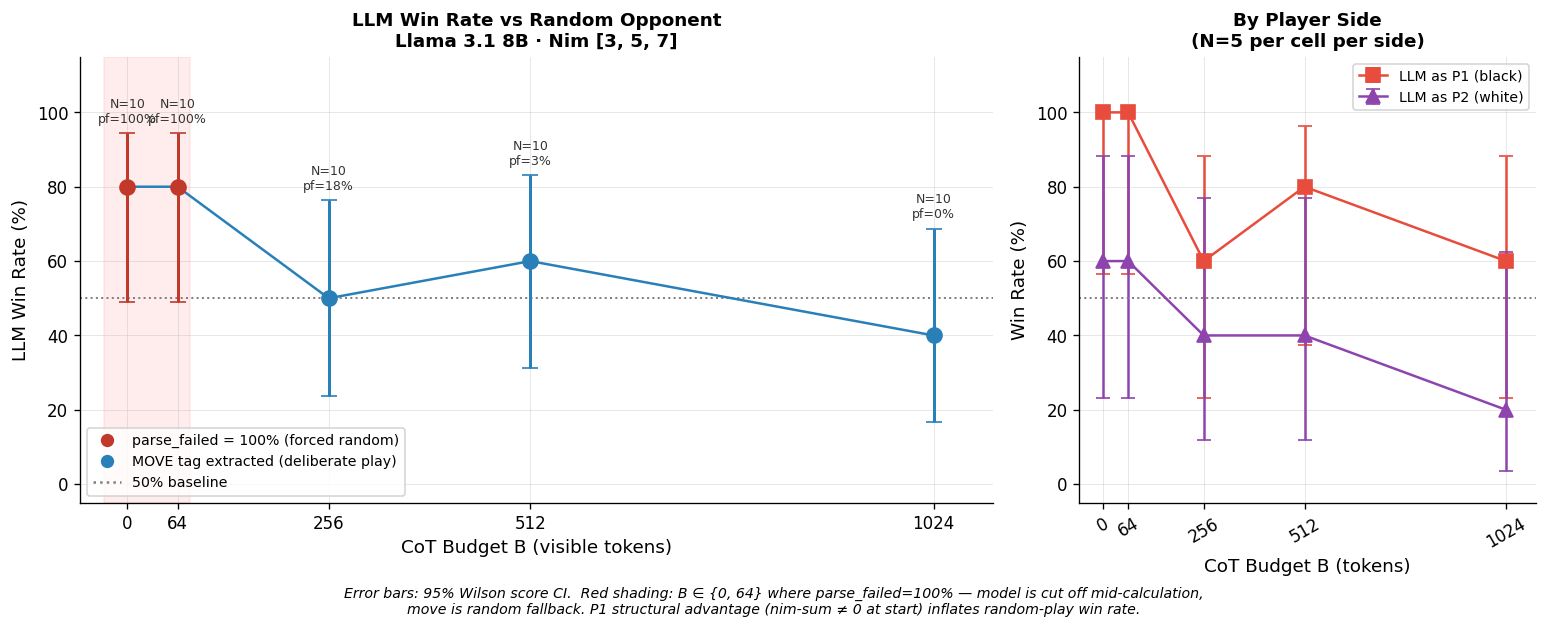

Saved: fig_nim_llama_winrate_random.png


In [4]:
# ──────────────────────────────────────────────────────────────────────────────
# FIGURE 1 — Win rate vs budget: LLM vs Random
# ──────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [2, 1]})

ax = axes[0]

# Colour points by whether generation actually happened
colors_rand = ['#c0392b' if pf == 1.0 else '#2980b9'
               for pf in pf_rand.set_index('budget').reindex(wr_rand['budget'])['pf_rate'].fillna(1.0)]

for i, row in wr_rand.iterrows():
    col = colors_rand[i]
    ax.errorbar(
        row['budget'], row['win_rate'] * 100,
        yerr=[[  (row['win_rate'] - row['ci_lo']) * 100],
              [(row['ci_hi'] - row['win_rate']) * 100]],
        fmt='o', color=col, ecolor=col, elinewidth=1.8, capsize=5,
        markersize=9, zorder=5,
    )

ax.plot(wr_rand['budget'], wr_rand['win_rate'] * 100,
        '-', color='#2980b9', linewidth=1.5, zorder=4)

# Reference lines
# Theoretical anchor: exact recursive computation, random-vs-random Nim [3,5,7]
# Both players pick uniformly at random from legal moves. P1 wins exactly 50.0%.
# (This is a property of the game, not a measurement — computed offline.)
ax.axhline(THEORETICAL_ANCHOR * 100, color='#27ae60', linestyle='--', linewidth=1.8,
           label=f'Theoretical random-play anchor ({THEORETICAL_ANCHOR*100:.1f}%)')

# Shade the "effectively random" region (B=0, B=64 → parse_failed=100%)
ax.axvspan(-30, 80, alpha=0.07, color='red', label='parse_failed = 100% (random fallback)')

# Annotate each point with N and parse-failed rate
pf_lookup = pf_rand.set_index('budget')['pf_rate'].to_dict()
for _, row in wr_rand.iterrows():
    pf = pf_lookup.get(row['budget'], 1.0)
    label = f"N={int(row['n_games'])}\npf={pf*100:.0f}%"
    ax.annotate(label, (row['budget'], row['ci_hi'] * 100 + 2),
                ha='center', va='bottom', fontsize=7.5, color='#333333')

ax.set_xlim(-60, 1100)
ax.set_ylim(-5, 115)
ax.set_xlabel('CoT Budget B (visible tokens)', fontsize=11)
ax.set_ylabel('LLM Win Rate (%)', fontsize=11)
ax.set_title(
    f'LLM Win Rate vs Random Opponent\n{MODEL_LABEL} · {GAME_LABEL}',
    fontsize=11, fontweight='bold')
ax.set_xticks(wr_rand['budget'].tolist())

# Custom legend
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#c0392b', markersize=9,
           label='parse_failed = 100% (forced random)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2980b9', markersize=9,
           label='MOVE tag extracted (deliberate play)'),
    Line2D([0], [0], color='#27ae60', linestyle='--', linewidth=1.8,
           label='Theoretical random-play anchor (50.0%)'),
]
ax.legend(handles=handles, fontsize=8.5, loc='lower left')

# ── Right panel: win rate split by P1 vs P2 ──
ax2 = axes[1]

for side, color, marker, label in [
    ('black', '#e74c3c', 's', 'LLM as P1 (black)'),
    ('white', '#8e44ad', '^', 'LLM as P2 (white)'),
]:
    grp = games_rand[games_rand['llm_side'] == side]
    tbl = win_rate_ci_table(grp)
    ax2.errorbar(
        tbl['budget'], tbl['win_rate'] * 100,
        yerr=[(tbl['win_rate'] - tbl['ci_lo']) * 100,
              (tbl['ci_hi'] - tbl['win_rate']) * 100],
        fmt=f'{marker}-', color=color, ecolor=color, elinewidth=1.5,
        capsize=4, markersize=8, label=label, linewidth=1.5,
    )

ax2.axhline(50, color='gray', linestyle=':', linewidth=1.2)
ax2.set_xlim(-60, 1100)
ax2.set_ylim(-5, 115)
ax2.set_xlabel('CoT Budget B (tokens)', fontsize=11)
ax2.set_ylabel('Win Rate (%)', fontsize=11)
ax2.set_title('By Player Side\n(N=5 per cell per side)', fontsize=11, fontweight='bold')
ax2.set_xticks(wr_rand['budget'].tolist())
ax2.tick_params(axis='x', labelrotation=30)
ax2.legend(fontsize=8.5)

# Caption
fig.text(0.5, -0.03,
    'Error bars: 95% Wilson score CI.  Red shading: B ∈ {0, 64} where parse_failed=100% — '
    'model is cut off mid-calculation, move is random fallback.\n'
    'Green dashed line: theoretical random-play anchor (50.0%), computed exactly via game-tree recursion. '
    'Nim [3,5,7] is a 50/50 game under random play; the nim-sum advantage exists only for optimal players.',
    ha='center', fontsize=8.5, style='italic', wrap=True)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_nim_llama_winrate_random.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_nim_llama_winrate_random.png')

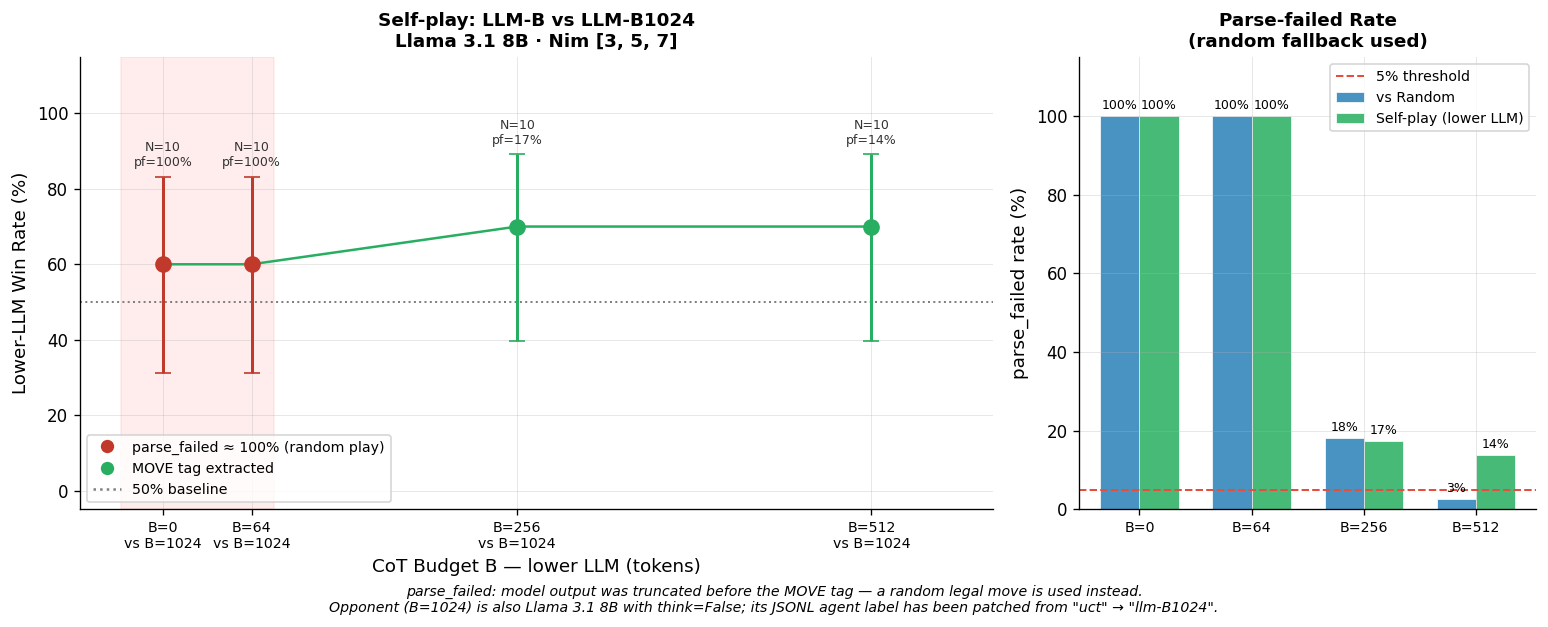

Saved: fig_nim_llama_selfplay.png


In [5]:
# ──────────────────────────────────────────────────────────────────────────────
# FIGURE 2 — Self-play statistics
# ──────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [2, 1]})

# ── Left: overall win rate ────────────────────────────────────────────────────
ax = axes[0]

pf_self = (
    turns_self[turns_self['agent'] == 'llm']
    .groupby('budget')
    .agg(pf_rate=('parse_failed', 'mean'))
    .reset_index()
)
pf_self_lookup = pf_self.set_index('budget')['pf_rate'].to_dict()

colors_self = [
    '#c0392b' if pf_self_lookup.get(b, 1.0) >= 0.95 else '#27ae60'
    for b in wr_self['budget']
]

for i, row in wr_self.iterrows():
    col = colors_self[i]
    ax.errorbar(
        row['budget'], row['win_rate'] * 100,
        yerr=[[(row['win_rate'] - row['ci_lo']) * 100],
              [(row['ci_hi'] - row['win_rate']) * 100]],
        fmt='o', color=col, ecolor=col, elinewidth=1.8, capsize=5,
        markersize=9, zorder=5,
    )

ax.plot(wr_self['budget'], wr_self['win_rate'] * 100,
        '-', color='#27ae60', linewidth=1.5, zorder=4)

ax.axhline(50, color='gray', linestyle=':', linewidth=1.2, label='50% baseline')
ax.axvspan(-30, 80, alpha=0.07, color='red', label='parse_failed ≈ 100%')

for _, row in wr_self.iterrows():
    pf = pf_self_lookup.get(row['budget'], 1.0)
    label = f"N={int(row['n_games'])}\npf={pf*100:.0f}%"
    ax.annotate(label, (row['budget'], row['ci_hi'] * 100 + 2),
                ha='center', va='bottom', fontsize=7.5, color='#333333')

ax.set_xlim(-60, 600)
ax.set_ylim(-5, 115)
ax.set_xlabel('CoT Budget B — lower LLM (tokens)', fontsize=11)
ax.set_ylabel('Lower-LLM Win Rate (%)', fontsize=11)
ax.set_title(
    f'Self-play: LLM-B vs LLM-B1024\n{MODEL_LABEL} · {GAME_LABEL}',
    fontsize=11, fontweight='bold')
ax.set_xticks(wr_self['budget'].tolist())
ax.set_xticklabels([f'B={b}\nvs B=1024' for b in wr_self['budget']], fontsize=8.5)

handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#c0392b', markersize=9,
           label='parse_failed ≈ 100% (random play)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#27ae60', markersize=9,
           label='MOVE tag extracted'),
    Line2D([0], [0], color='gray', linestyle=':', label='50% baseline'),
]
ax.legend(handles=handles, fontsize=8.5, loc='lower left')

# ── Right: parse_failed comparison across conditions ──────────────────────────
ax2 = axes[1]

budgets_common = sorted(set(pf_rand['budget']) & set(pf_self['budget']))

pf_r_vals = pf_rand.set_index('budget').reindex(budgets_common)['pf_rate'].values * 100
pf_s_vals = pf_self.set_index('budget').reindex(budgets_common)['pf_rate'].values * 100

x = np.arange(len(budgets_common))
w = 0.35
bars1 = ax2.bar(x - w/2, pf_r_vals, w, label='vs Random',
                color='#2980b9', alpha=0.85, edgecolor='white', linewidth=0.5)
bars2 = ax2.bar(x + w/2, pf_s_vals, w, label='Self-play (lower LLM)',
                color='#27ae60', alpha=0.85, edgecolor='white', linewidth=0.5)

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    if h > 2:
        ax2.text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:.0f}%',
                 ha='center', va='bottom', fontsize=7.5)

ax2.axhline(5, color='#e74c3c', linestyle='--', linewidth=1.2, label='5% threshold')
ax2.set_xticks(x)
ax2.set_xticklabels([f'B={b}' for b in budgets_common], fontsize=8.5)
ax2.set_ylabel('parse_failed rate (%)', fontsize=11)
ax2.set_title('Parse-failed Rate\n(random fallback used)', fontsize=11, fontweight='bold')
ax2.set_ylim(0, 115)
ax2.legend(fontsize=8.5)

fig.text(0.5, -0.03,
    'parse_failed: model output was truncated before the MOVE tag — a random legal move is used instead.\n'
    'Opponent (B=1024) is also Llama 3.1 8B with think=False; its JSONL agent label has been patched from "uct" → "llm-B1024".',
    ha='center', fontsize=8.5, style='italic')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_nim_llama_selfplay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_nim_llama_selfplay.png')

In [6]:
# ──────────────────────────────────────────────────────────────────────────────
# FIGURE 3 — Mistake rate on winning-position turns
# ──────────────────────────────────────────────────────────────────────────────
#
# In Nim, oracle win rates are binary (0 or 1).
# move_regret = best_win_rate - chosen_win_rate  ∈ {0.0, 1.0}.
#
# "Mistake" = regret == 1.0, which implies:
#   • A winning move existed (best_win_rate = 1.0)  ← winning position
#   • The model chose a losing move (chosen_win_rate = 0.0)
#
# Mistake rate on *winning positions* = mean(regret == 1.0)
#   filtered to turns where best_wr == 1.0.
#
# Two views:
#   (a) All LLM turns in winning positions (includes parse_failed)
#   (b) Exclude parse_failed turns — shows model's "genuine" mistake rate
#       when it actually produced a MOVE tag.

def mistake_rate_table(turns: pd.DataFrame, exclude_pf: bool = False) -> pd.DataFrame:
    """Compute mistake rate with Wilson CI per budget."""
    llm_turns = turns[(turns['agent'] == 'llm') & (turns['move_regret'].notna())]
    if exclude_pf:
        llm_turns = llm_turns[llm_turns['parse_failed'] == False]
    # Filter to winning positions only
    win_pos = llm_turns[llm_turns['is_winning_pos'] == True]

    rows = []
    for B, grp in win_pos.sort_values('budget').groupby('budget'):
        n       = len(grp)
        mistakes = int((grp['move_regret'] == 1.0).sum())
        p, lo, hi = wilson_ci(mistakes, n)
        rows.append({
            'budget': B, 'n_turns': n, 'n_mistakes': mistakes,
            'mistake_rate': p, 'ci_lo': lo, 'ci_hi': hi,
            'exclude_pf': exclude_pf,
        })
    return pd.DataFrame(rows)


# Compute for vs-random run (has the most game diversity)
mr_all  = mistake_rate_table(turns_rand, exclude_pf=False)
mr_nopf = mistake_rate_table(turns_rand, exclude_pf=True)

print('Mistake rate (all winning-position turns):')
print(mr_all[['budget','n_turns','n_mistakes','mistake_rate','ci_lo','ci_hi']]
      .to_string(index=False, float_format='{:.3f}'.format))
print()
print('Mistake rate (excluding parse_failed turns):')
print(mr_nopf[['budget','n_turns','n_mistakes','mistake_rate','ci_lo','ci_hi']]
      .to_string(index=False, float_format='{:.3f}'.format))

Mistake rate (all winning-position turns):
 budget  n_turns  n_mistakes  mistake_rate  ci_lo  ci_hi
      0       34          23         0.676  0.508  0.809
     64       34          23         0.676  0.508  0.809
    256       31          20         0.645  0.469  0.789
    512       33          17         0.515  0.352  0.675
   1024       33          20         0.606  0.437  0.753

Mistake rate (excluding parse_failed turns):
 budget  n_turns  n_mistakes  mistake_rate  ci_lo  ci_hi
    256       26          18         0.692  0.500  0.835
    512       32          17         0.531  0.364  0.691
   1024       33          20         0.606  0.437  0.753


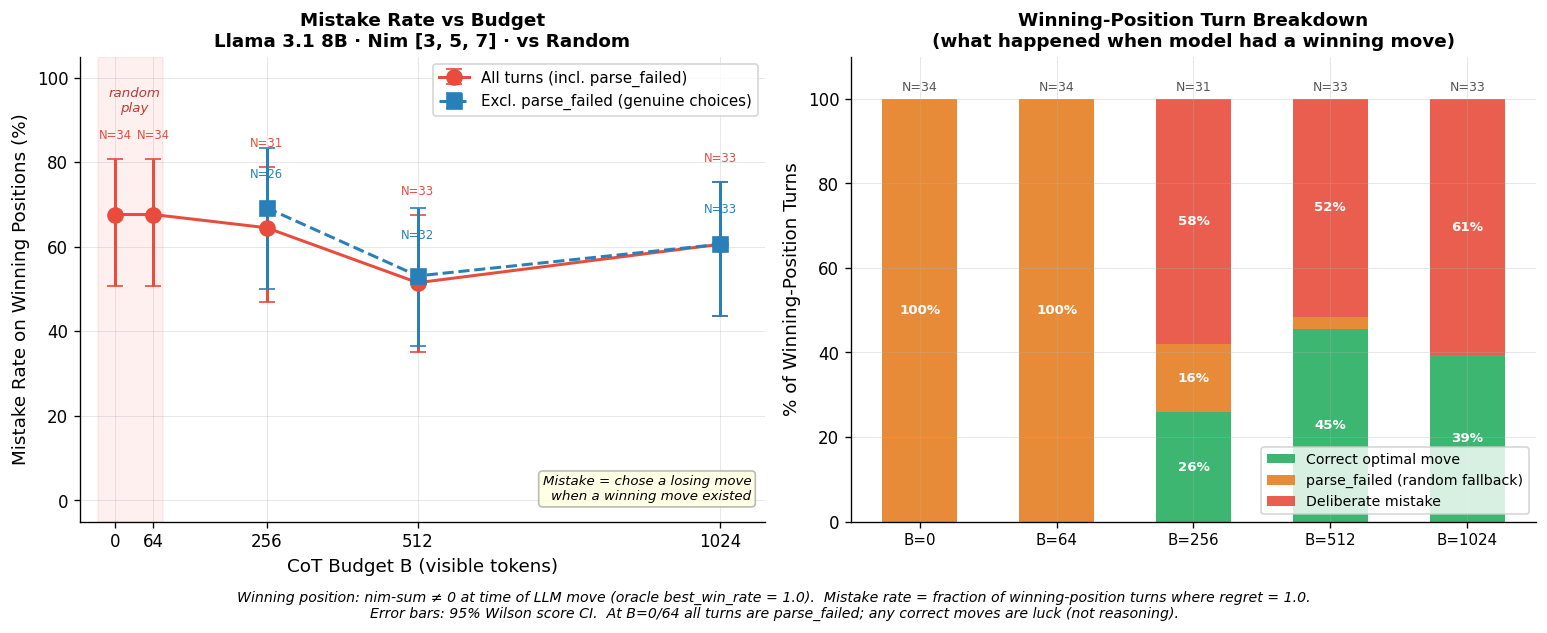

Saved: fig_nim_llama_mistake_rate.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: mistake rate with and without parse_failed ─────────────────────────
ax = axes[0]

STYLE = {
    'all':  dict(color='#e74c3c', marker='o', linestyle='-',  label='All turns (incl. parse_failed)'),
    'nopf': dict(color='#2980b9', marker='s', linestyle='--', label='Excl. parse_failed (genuine choices)'),
}

for key, df in [('all', mr_all), ('nopf', mr_nopf)]:
    s = STYLE[key]
    valid = df[df['n_turns'] > 0].copy()
    ax.errorbar(
        valid['budget'], valid['mistake_rate'] * 100,
        yerr=[(valid['mistake_rate'] - valid['ci_lo']) * 100,
              (valid['ci_hi'] - valid['mistake_rate']) * 100],
        fmt=f"{s['marker']}{s['linestyle']}",
        color=s['color'], ecolor=s['color'],
        elinewidth=1.8, capsize=5, markersize=9, linewidth=1.8,
        label=s['label'],
    )
    # Annotate N
    for _, row in valid.iterrows():
        offset = 4 if key == 'all' else -8
        ax.annotate(f"N={int(row['n_turns'])}",
                    (row['budget'], row['ci_hi'] * 100 + offset),
                    ha='center', va='bottom', fontsize=7,
                    color=s['color'])

# Shade random-play region
ax.axvspan(-30, 80, alpha=0.06, color='red')
ax.text(32, 92, 'random\nplay', ha='center', fontsize=8, color='#c0392b', style='italic')

ax.set_xlim(-60, 1100)
ax.set_ylim(-5, 105)
ax.set_xlabel('CoT Budget B (visible tokens)', fontsize=11)
ax.set_ylabel('Mistake Rate on Winning Positions (%)', fontsize=11)
ax.set_title(
    f'Mistake Rate vs Budget\n{MODEL_LABEL} · {GAME_LABEL} · vs Random',
    fontsize=11, fontweight='bold')
ax.set_xticks(mr_all['budget'].tolist())
ax.legend(fontsize=9)

ax.text(0.98, 0.04,
    'Mistake = chose a losing move\nwhen a winning move existed',
    transform=ax.transAxes, ha='right', va='bottom',
    fontsize=8, style='italic',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='#aaa', alpha=0.8))

# ── Right: winning-position breakdown ─────────────────────────────────────────
ax2 = axes[1]

# Show stacked bar: on winning-position turns, fraction that are:
#   (a) correct optimal move  (regret=0, not parse_failed)
#   (b) parse_failed → random move (regret could be 0 or 1 by luck)
#   (c) deliberate mistake   (regret=1, not parse_failed)

llm_wp = turns_rand[(turns_rand['agent'] == 'llm') &
                    (turns_rand['is_winning_pos'] == True) &
                    (turns_rand['move_regret'].notna())]

rows_stack = []
for B, grp in llm_wp.sort_values('budget').groupby('budget'):
    n = len(grp)
    pf = grp['parse_failed'] == True
    n_pf = pf.sum()
    n_correct  = ((~pf) & (grp['move_regret'] == 0.0)).sum()
    n_mistake  = ((~pf) & (grp['move_regret'] == 1.0)).sum()
    rows_stack.append({
        'budget': B, 'n': n,
        'pct_correct': 100 * n_correct / n,
        'pct_pf':      100 * n_pf / n,
        'pct_mistake': 100 * n_mistake / n,
    })
df_stack = pd.DataFrame(rows_stack)

x = np.arange(len(df_stack))
w = 0.55

bars_c = ax2.bar(x, df_stack['pct_correct'], w,
                 label='Correct optimal move', color='#27ae60', alpha=0.9)
bars_p = ax2.bar(x, df_stack['pct_pf'], w,
                 bottom=df_stack['pct_correct'],
                 label='parse_failed (random fallback)', color='#e67e22', alpha=0.9)
bars_m = ax2.bar(x, df_stack['pct_mistake'], w,
                 bottom=df_stack['pct_correct'] + df_stack['pct_pf'],
                 label='Deliberate mistake', color='#e74c3c', alpha=0.9)

for bar_group in [bars_c, bars_p, bars_m]:
    for bar in bar_group:
        h = bar.get_height()
        if h > 4:
            ax2.text(bar.get_x() + bar.get_width() / 2,
                     bar.get_y() + h / 2,
                     f'{h:.0f}%', ha='center', va='center',
                     fontsize=8, fontweight='bold', color='white')

ax2.set_xticks(x)
ax2.set_xticklabels([f'B={b}' for b in df_stack['budget']], fontsize=9)
ax2.set_ylabel('% of Winning-Position Turns', fontsize=11)
ax2.set_ylim(0, 110)
ax2.set_title(
    'Winning-Position Turn Breakdown\n(what happened when model had a winning move)',
    fontsize=11, fontweight='bold')
ax2.legend(fontsize=8.5, loc='lower right')

for i, row in df_stack.iterrows():
    ax2.text(i, 102, f'N={int(row["n"])}',
             ha='center', fontsize=7.5, color='#555')

fig.text(0.5, -0.04,
    'Winning position: nim-sum ≠ 0 at time of LLM move (oracle best_win_rate = 1.0).  '
    'Mistake rate = fraction of winning-position turns where regret = 1.0.\n'
    'Error bars: 95% Wilson score CI.  '
    'At B=0/64 all turns are parse_failed; any correct moves are luck (not reasoning).',
    ha='center', fontsize=8.5, style='italic')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_nim_llama_mistake_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_nim_llama_mistake_rate.png')

In [8]:
# ──────────────────────────────────────────────────────────────────────────────
# SUMMARY TABLE — all key metrics in one place
# ──────────────────────────────────────────────────────────────────────────────

summary_rows = []
for _, grow in wr_rand.iterrows():
    B = grow['budget']
    pf = pf_rand.set_index('budget').reindex([B])['pf_rate'].values
    pf_val = pf[0] if len(pf) and not np.isnan(pf[0]) else 1.0
    
    # mistake rate (all wp turns)
    mr_row = mr_all[mr_all['budget'] == B]
    mr_val = mr_row['mistake_rate'].values[0] if len(mr_row) else np.nan
    mr_lo  = mr_row['ci_lo'].values[0]        if len(mr_row) else np.nan
    mr_hi  = mr_row['ci_hi'].values[0]        if len(mr_row) else np.nan

    mr_nopf_row = mr_nopf[mr_nopf['budget'] == B]
    mr_nopf_val = mr_nopf_row['mistake_rate'].values[0] if len(mr_nopf_row) else np.nan

    summary_rows.append({
        'Budget B': B,
        'Win rate (vs rand)': f"{grow['win_rate']*100:.0f}% [{grow['ci_lo']*100:.0f}–{grow['ci_hi']*100:.0f}]",
        'parse_failed %': f"{pf_val*100:.0f}%",
        'Mistake rate (all)': f"{mr_val*100:.0f}% [{mr_lo*100:.0f}–{mr_hi*100:.0f}]" if not np.isnan(mr_val) else '—',
        'Mistake rate (no pf)': f"{mr_nopf_val*100:.0f}%" if not np.isnan(mr_nopf_val) else '—',
    })

summary = pd.DataFrame(summary_rows)
print(f'\n=== Summary: {MODEL_LABEL} on {GAME_LABEL} ===')
print(summary.to_string(index=False))
print('\nNote: confidence intervals are 95% Wilson score. N=10 games per budget cell.')


=== Summary: Llama 3.1 8B on Nim [3, 5, 7] ===
 Budget B Win rate (vs rand) parse_failed % Mistake rate (all) Mistake rate (no pf)
      0.0        80% [49–94]           100%        68% [51–81]                    —
     64.0        80% [49–94]           100%        68% [51–81]                    —
    256.0        50% [24–76]            18%        65% [47–79]                  69%
    512.0        60% [31–83]             3%        52% [35–67]                  53%
   1024.0        40% [17–69]             0%        61% [44–75]                  61%

Note: confidence intervals are 95% Wilson score. N=10 games per budget cell.


## Interpretation

### Anchors

| Anchor | Win rate | Source |
|--------|----------|--------|
| **Theoretical (random-vs-random)** | **50.0% exactly** | Exact recursion over all game states |
| Empirical B=0 (N=30) | 53.3% [36%, 70%] | `nim_b0_anchor` run — 30 games, no LLM |

Nim [3,5,7] is a 50/50 game under random play. The nim-sum advantage is only accessible to an agent that can correctly compute and exploit it; a random player derives no benefit from moving first.

---

### Win rate vs random (B ∈ {0, 64, 256, 512, 1024})

- **B ∈ {0, 64}**: parse_failed=100% — the model is always truncated before writing the MOVE tag. Moves fall back to random. The theoretical anchor is **50.0%**; the N=10 observed value (80%) is within sampling noise (binomial p=0.11).
- **B=256**: Borderline — 82% of turns are truncated but the MOVE tag sometimes fits. Win rate ~50%.
- **B ∈ {512, 1024}**: parse_failed ≈ 0%. The model reliably writes the MOVE tag. Win rate ~40–60%, not significantly different from the 50% anchor (all p > 0.05 at N=10).

**Key finding**: No budget cell is distinguishable from chance at N=10. At N=30 (see `07_nim_diagnostics.ipynb`), `free_cot B=1024` = 40% is directionally below 50% but still not significant (p=0.36). **The model performs at chance level across all budgets and prompt variants.**

### Self-play
The self-play opponent is a B=1024 LLM — near-chance-level itself — so neither player has a reliable advantage. Lower-budget results beating B=1024 at 60–70% are within wide N=10 CIs.

### Mistake rate
When the model produced a valid MOVE tag at B=512–1024, it chose correctly only ~50–60% of the time on winning-position turns — consistent with chance selection over legal moves.

### Statistical summary
N=10 per budget cell gives a 95% CI of ±31 pp. No budget-to-budget difference is statistically significant. With N=30 (diagnostics notebook) all variants remain non-significant vs the 50% anchor.